
<br>
    The objective of this exercise is to study the signal of ECG during atrial<br>
    fibrilation (AF). The signal analysed contains different type of AF with<br>
    stable repolarisation loops and random AF.<br>


In [1]:
import numpy as np
import pylab as py
py.ion()
py.close('all')
import scipy.signal as sp


<br>
    The first signal is an ECG with atrial fibrilation.<br>
    Q: What are the differences of this ECG with a normal ECG?<br>


In [2]:
ecg = np.genfromtxt('ecg_af.dat')
ecg_fs = 300
t_ecg = np.arange(len(ecg))/ecg_fs

(210.0, 215.0)

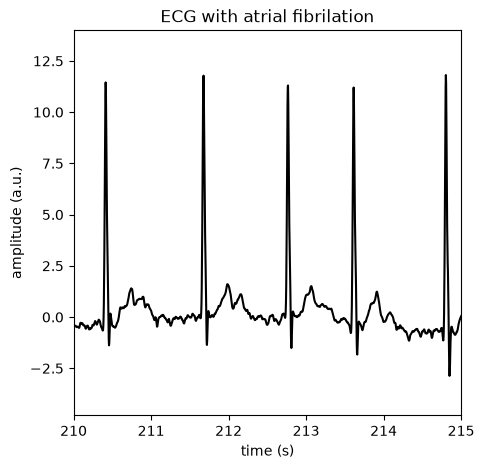

In [3]:
py.figure(1,figsize=[5,5])
py.plot(t_ecg, ecg, 'k')
py.xlabel('time (s)')
py.ylabel('amplitude (a.u.)')
py.title('ECG with atrial fibrilation')
py.xlim(210, 215)

### Answer
In a normal ECG, each QRS complex is preceded by a small, distinct P wave (atrial depolarisation) and followed by a T wave (ventricular repolarisation), with a flat baseline in between. The QRS complexes also come at regular intervals.

Differences of this ECG:
- There are no distinct P waves. The baseline between the QRS complexes shows small, fast, irregular oscillations (fibrillatory "f-waves"). They come from chaotic, uncoordinated electrical activity in the atria.
- The R–R intervals are irregular. The ventricular rhythm is irregular because the disorganised atrial impulses reach the AV node at random times and only some of them are conducted.

PS: The QRS complexes themselves still look normal, because conduction through the ventricles is unaffected.


<br>
    We compute the autocorelation of the ECG signal.<br>
    In order to discard the modulation of the baseline we first apply a<br>
    high-pass filter with a cut-off frequency of 0.5 Hz.<br>
    Q: Do you see a specific pattern that permits to characterize the atrial<br>
        fibrilation?<br>


In [4]:
b, a = sp.butter(2, 0.5/ecg_fs*2, btype='high')

In [5]:
ecg_hp = sp.filtfilt(b, a, ecg)

In [6]:
rxx_ecg = np.correlate(ecg_hp, ecg_hp, mode='full') 
k = np.arange(len(rxx_ecg))-len(rxx_ecg)//2

(-500.0, 500.0)

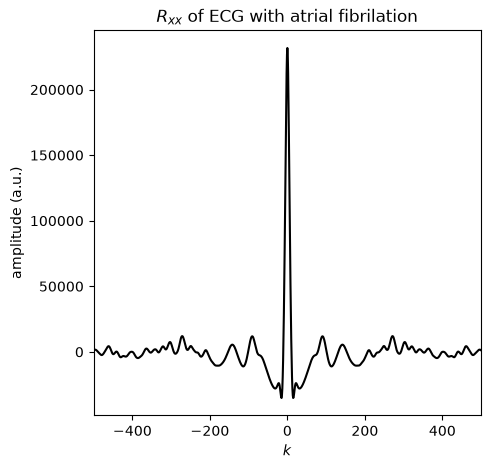

In [7]:
py.figure(2,figsize=[5,5])
py.plot(k, rxx_ecg, 'k')
py.xlabel('$k$')
py.ylabel('amplitude (a.u.)')
py.title('$R_{xx}$ of ECG with atrial fibrilation')
py.xlim(-500, 500)

### Answer
Yes, the pattern that characterizes the AF is the absence of periodicity in the R_xx plot.

For a normal ECG the beats are similar and regularly spaced so the R_xx would show clear peaks at the R–R period and its multiples. In this plot, R_xx has one sharp peak at k = 0 and beyond that there are only small, irregular fluctuations and no dominant peak at any lag. 

So, the QRS complexes all look alike but the irregular R–R intervals mean their contributions do not add up at a common lag and are instead spread over many lags. This loss of periodicity reflects the irregular ventricular rhythm caused by AF.


<br>
    Compute the PSD of the ECG signal.<br>
    Q: What do you see?<br>


In [8]:
f, ECG = sp.welch(ecg_hp, nperseg=500, nfft=4096, noverlap=250, fs=ecg_fs)

(0.0, 60.0)

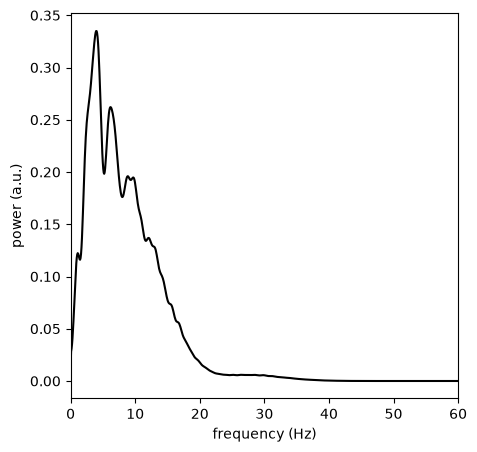

In [9]:
py.figure(3, figsize=[5,5])
py.clf()
py.plot(f, ECG, 'k')
py.xlabel('frequency (Hz)')
py.ylabel('power (a.u.)')
py.xlim(0,60)

### Answer
The power is concentrated at low frequencies (between about 1 and 20 Hz), with a maximum around 4 Hz. Above ~30 Hz there is almost no power, and below 0.5 Hz it drops to zero because of the high-pass filter.

This is because the ECG consists of relatively slow waves. The QRS complexes contain most of the energy and lie roughly between 5 and 20 Hz, while T waves and atrial activity are even slower.

For a normal ECG, we would expect sharp peaks at the heart rate and its harmonics. For the AF ECG, the spectrum is broad and unstructured because the R–R intervals are irregular. In addition, the dominant QRS complexes mask the atrial activity.


<br>
    In order to higlight the signal related to the repolarisation of the<br>
    atria and ECG, signal with atrial fibrilation has been process, keeping only<br>
    the P wave (repolarisation of the atria) and the QRST waves have been<br>
    removed.<br>
    During the measurement 4 time segments exhibit different behaviors.<br>
    Q: What are the difference between the different segments ?<br>


In [10]:
p_wave = np.genfromtxt('AF_sync.dat')
p_wave_fs = 50
t_p_wave = np.arange(len(p_wave))/p_wave_fs

In [11]:
segments = [1500, 2000, 2500, 3000, 3500]

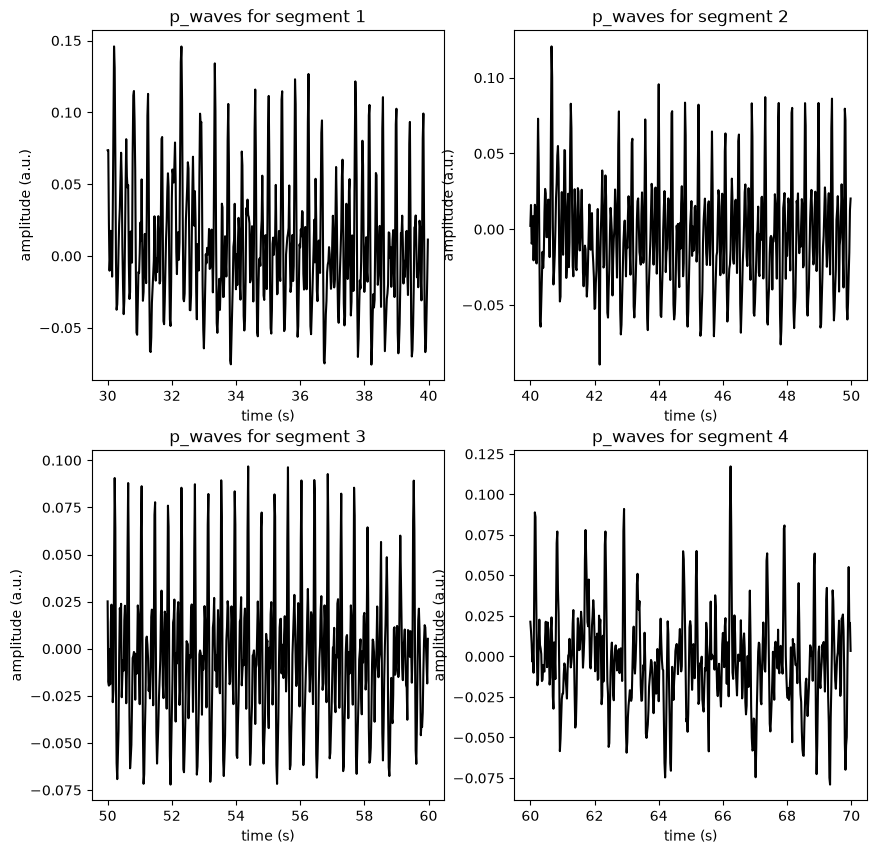

In [12]:
py.figure(4,figsize=[10,10])
for n in range(len(segments)-1):
    py.subplot(2, 2, int(n+1))
    idx = np.arange(segments[n], segments[n+1])
    py.plot(t_p_wave[idx], p_wave[idx], 'k')
    py.xlabel('time (s)')
    py.ylabel('amplitude (a.u.)')
    py.title('p_waves for segment '+str(n+1))

### Answer
The four segments differ in how regular and repetitive the atrial activity is:

- **Segment 1 (30–40 s):** Large, sharp deflections (the highest amplitude of the four segments). The activity is fairly regular, but the spacing and amplitude of the peaks vary. 
- **Segment 2 (40–50 s):** Irregular during the first few seconds, then it settles into a regular pattern where the same waveform repeats. It becomes organised during the segment.
- **Segment 3 (50–60 s):** The most regular segment. The same waveform repeats throughout the whole segment. This suggests a stable re-entry loop in the atria.
- **Segment 4 (60–70 s):** Irregular, with peaks at random intervals, varying shapes and a lower amplitude. There is no repeating pattern and it looks like noise, which corresponds to random AF.

So segments 2 and 3 (and partly 1) show organised AF with a stable repeating cycle, while segment 4 shows disorganised, random AF.



<br>
    We compute the autocorelation of the p_wave signal.<br>
    In order to dircard the modulation of the baseline we first apply a<br>
    high-pass filter with a cut-off frequency of 0.5 Hz.<br>
    <br>
    Q: Do you see a specific pattern that permits to characterize the atrial<br>
        fibrilation?<br>
    Q: Discuss the organisation of the signals. Which one is the more organised,<br>
        which one is closer to a noise?<br>


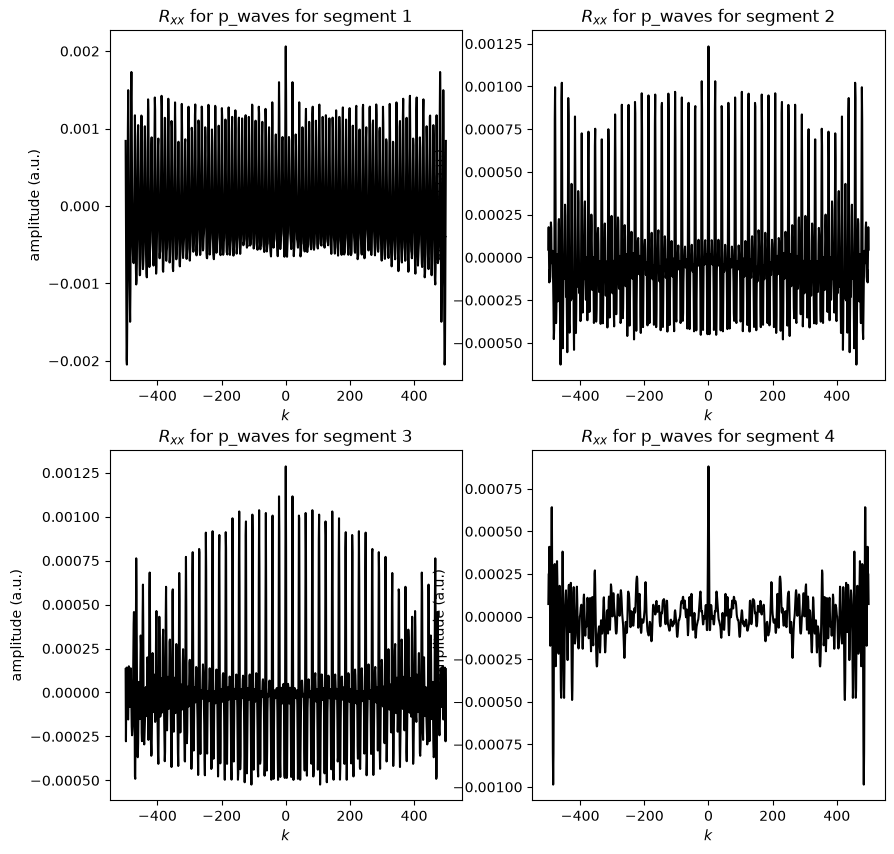

In [13]:
py.figure(5,figsize=[10,10])
for n in range(len(segments)-1):
    py.subplot(2, 2, int(n+1))
    idx = np.arange(segments[n], segments[n+1])
    rxx_p_wave = np.correlate(p_wave[idx], p_wave[idx], mode='full') 
    rxx_p_wave /= np.correlate(np.ones(len(idx)), np.ones(len(idx)), mode='full')
    k = np.arange(len(rxx_p_wave))-len(rxx_p_wave)//2
    py.plot(k, rxx_p_wave, 'k')
    py.xlabel('$k$')
    py.ylabel('amplitude (a.u.)')
    py.title('$R_{xx}$ for p_waves for segment '+str(n+1))

### Answer
Yes. The autocorrelation clearly distinguishes organised AF from random AF: organised segments give a periodic R_xx, while random AF gives an R_xx with only a peak at k = 0.

- **Segment 1:** R_xx is periodic, with peaks every ~10 samples. Every second peak is higher, so the underlying cycle is ~20 samples, with a second, smaller deflection in the middle of each cycle. The activity is organised, but less cleanly than in segments 2 and 3, where there is no significant peak at half a cycle.
- **Segment 2:** Strong peaks every ~20 samples. The peaks at half a cycle are negligible compared to segment 1. The activity is organised.
- **Segment 3:** The clearest and strongest periodic pattern, with peaks every ~20 samples. It is the most organised segment, consistent with a stable re-entry loop.
- **Segment 4:** Only one peak at k = 0 and small, irregular fluctuations, in the rest of the plot (the side values are close to 0). There is no repeating pattern, so this segment is the closest to noise (random AF).

PS: The spikes at the edges of the plots (|k| close to 500) should be ignored: because R_xx is normalised by the number of overlapping samples, only a few samples are averaged there, so the estimate is very noisy.


<br>
    Compute the PSD of the p_wave signal.<br>
    Q: What do you see?<br>
    Q: Which one is the more organised?<br>
    Q: Which ones looks like a noise?<br>
    Q: Which ones exhibit a sustained repolarisation loop?<br>


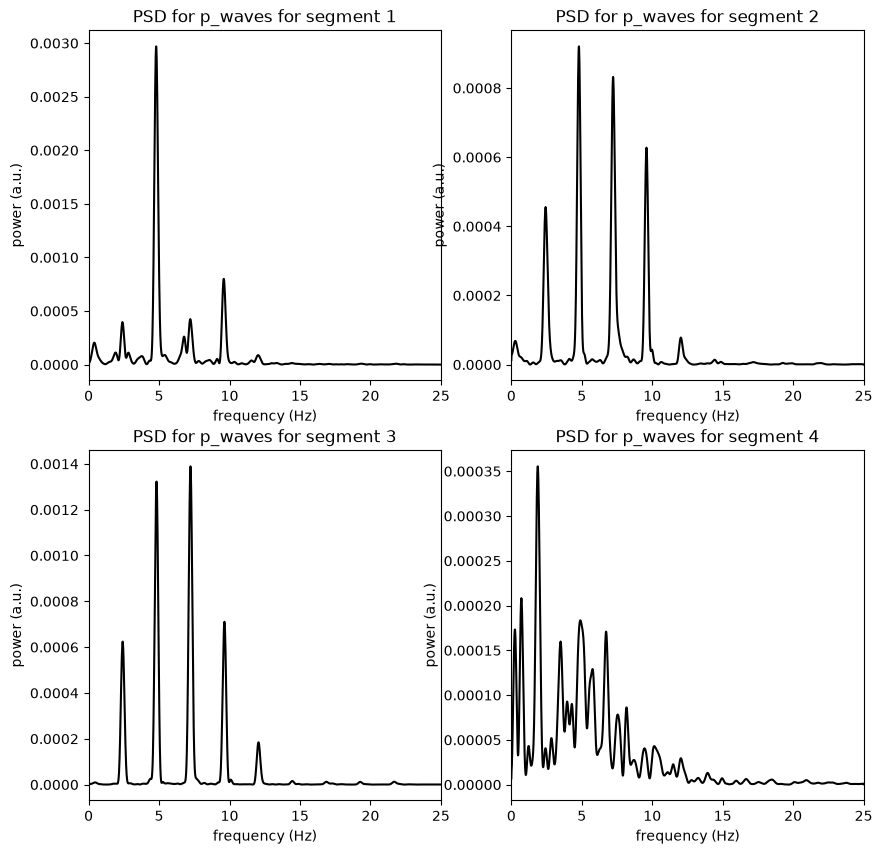

In [14]:
py.figure(7, figsize=[10,10])
for n in range(len(segments)-1):
    idx = np.arange(segments[n], segments[n+1])
    f, P_WAVE = sp.welch(p_wave[idx], nperseg=250, nfft=4096, noverlap=100, fs=p_wave_fs)
    py.subplot(2, 2, int(n+1))
    py.plot(f, P_WAVE, 'k')
    py.xlabel('frequency (Hz)')
    py.ylabel('power (a.u.)')
    py.xlim(0,25)
    py.title('PSD for p_waves for segment '+str(n+1))

### Answer
Segment 1, 2 and 3 all share 4 distinct peaks at about 2.5, 5, 7.5 and 10 Hz. 
- **Segment 1:** There is one very strong, distinct, peak at 10 Hz but the other peaks are much lower. The peak at 10 Hz is much lower but still distinct and the peaks at 2.5 and 7.5 are very low and their shape is disturbed.
- **Segment 2 and 3:** They are very similar. Both have very similar disctinct peaks but segment 3 is better as they are stronger and the baseline is flatter.
- **Segment 4:** Very messy, one distinguishable peak at 2Hz but the rest is a mess.

Segment 3 is the most organised and exhibits a sustained repolarisation loop, showing organised AF and segment 4 is the least organised showing clear random AF.

### Answer
Segments 1, 2 and 3 all show distinct peaks at about 2.5, 5, 7.5 and 10 Hz.
- **Segment 1:** One very strong, distinct peak at ~5 Hz. The peak at ~10 Hz is much lower but still distinct. The peaks at 2.4 and 7.2 Hz are very low and their shape is split.
- **Segments 2 and 3:** Very similar, both with sharp, distinct peaks. Segment 3 is more organised: the peaks are stronger and the baseline between the peaks is flatter.
- **Segment 4:** Very disorganised. There is one distinguishable peak at ~2 Hz, but otherwise the power is spread over many small, irregular peaks between 0 and ~12 Hz, like noise.

Segment 3 is the most organised and exhibits a sustained re-entry loop, showing organised AF. Segment 4 is the least organised, showing clear random AF.